In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os
folder = '/content/drive/MyDrive/insider-threat-project/'

for file in os.listdir(folder):
    if file.endswith('.zip'):
        print(f"Extracting: {file}")
        with zipfile.ZipFile(folder + file, 'r') as z:
            z.extractall(folder)

print("All files extracted!")
print("\nFiles now available:")
print(os.listdir(folder))

Extracting: logon.csv.zip
Extracting: device.csv.zip
Extracting: file.csv.zip
All files extracted!

Files now available:
['logon.csv.zip', 'device.csv.zip', 'file.csv.zip', 'users.csv', 'logon.csv', 'device.csv', 'file.csv']


In [4]:
import pandas as pd
folder = '/content/drive/MyDrive/insider-threat-project/'
logon   = pd.read_csv(folder + 'logon.csv')
file_df = pd.read_csv(folder + 'file.csv')
device  = pd.read_csv(folder + 'device.csv')
users   = pd.read_csv(folder + 'users.csv')

print("All datasets loaded!")
print(f"Logon:  {logon.shape}")
print(f"File:   {file_df.shape}")
print(f"Device: {device.shape}")
print(f"Users:  {users.shape}")

All datasets loaded!
Logon:  (3530285, 5)
File:   (2014883, 9)
Device: (1551828, 6)
Users:  (4000, 12)


In [5]:
print("LOGON FILE DATA ")
display(logon.head(3))
print(logon.dtypes)

print("\nFILE ACCESS DATA")
display(file_df.head(3))
print(file_df.dtypes)

print("\nDEVICE FILE DATA")
display(device.head(3))
print(device.dtypes)

print("\nUSERS FILE DATA")
display(users.head(3))
print(users.dtypes)

LOGON FILE DATA 


,id,date,user,pc,activity
0,{F3X8-Y2GT43DR-4906OHBL},01/02/2010 02:19:18,DNS1758,PC-0414,Logon
1,{B4Q0-D0GM24KN-3704MAII},01/02/2010 02:31:12,DNS1758,PC-0414,Logoff
2,{T7J1-D4HK34KV-5476TCIJ},01/02/2010 02:34:02,DNS1758,PC-5313,Logon


id          object
date        object
user        object
pc          object
activity    object
dtype: object

FILE ACCESS DATA


,id,date,user,pc,filename,activity,to_removable_media,from_removable_media,content
0,{F3E2-X3MV05YQ-3516SZDT},01/02/2010 07:19:41,SDH2394,PC-5849,R:\60WBQE7S.doc,File Open,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
1,{I6N1-Z7VL92UY-8715ESKQ},01/02/2010 07:21:30,SDH2394,PC-5849,R:\0VGILDW8.pdf,File Write,True,False,25-50-44-46-2D ---- Bengali As do many other T...
2,{G4X5-J7MH70FV-8936QVSB},01/02/2010 07:22:11,SDH2394,PC-5849,R:\60WBQE7S.doc,File Copy,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."


id                      object
date                    object
user                    object
pc                      object
filename                object
activity                object
to_removable_media        bool
from_removable_media      bool
content                 object
dtype: object

DEVICE FILE DATA


,id,date,user,pc,file_tree,activity
0,{Z2Q8-K3AV28BE-9353JIRT},01/02/2010 07:17:18,SDH2394,PC-5849,R:\;R:\22B5gX4;R:\SDH2394,Connect
1,{C7F1-G7LE60RU-2483DAXS},01/02/2010 07:22:42,JKS2444,PC-6961,R:\;R:\JKS2444,Connect
2,{T9A4-D4RV69OF-1704NINW},01/02/2010 07:31:42,CBA1023,PC-1570,R:\;R:\42gY283;R:\48rr4y2;R:\59ntt61;R:\76xCQG...,Connect


id           object
date         object
user         object
pc           object
file_tree    object
activity     object
dtype: object

USERS FILE DATA


,employee_name,user_id,email,role,projects,business_unit,functional_unit,department,team,supervisor,start_date,end_date
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,NaN,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12-01 00:00:00,2011-06-01
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,NaN,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12-01 00:00:00,2011-06-01
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,NaN,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12-01 00:00:00,2011-06-01


employee_name      object
user_id            object
email              object
role               object
projects           object
business_unit       int64
functional_unit    object
department         object
team               object
supervisor         object
start_date         object
end_date           object
dtype: object


In [6]:
#convert data
logon['date']  = pd.to_datetime(logon['date'])
file_df['date'] = pd.to_datetime(file_df['date'])
device['date'] = pd.to_datetime(device['date'])
print("Dates converted")

Dates converted


In [7]:
#missing values check
print("MISSING VALUES")
print("Logon:\n",  logon.isnull().sum())
print("\nFile:\n",  file_df.isnull().sum())
print("\nDevice:\n", device.isnull().sum())
print("\nUsers:\n",  users.isnull().sum())

MISSING VALUES
Logon:
 id          0
date        0
user        0
pc          0
activity    0
dtype: int64

File:
 id                      0
date                    0
user                    0
pc                      0
filename                0
activity                0
to_removable_media      0
from_removable_media    0
content                 0
dtype: int64

Device:
 id                0
date              0
user              0
pc                0
file_tree    773474
activity          0
dtype: int64

Users:
 employee_name         0
user_id               0
email                 0
role                  0
projects           3317
business_unit         0
functional_unit       2
department           22
team                158
supervisor            1
start_date            0
end_date              0
dtype: int64


In [8]:
# Fill missing categorical values in users table
users['projects'] = users['projects'].fillna('Unknown')
users['functional_unit'] = users['functional_unit'].fillna('Unknown')
users['department'] = users['department'].fillna('Unknown')
users['team'] = users['team'].fillna('Unknown')
users['supervisor'] = users['supervisor'].fillna('Unknown')
print(" Missing values handled!")

 Missing values handled!


In [9]:
# Extract time features
logon['hour']    = logon['date'].dt.hour
logon['day']     = logon['date'].dt.dayofweek # 0=Monday, 6=Sunday
logon['is_weekend'] = logon['day'].isin([5, 6]).astype(int)
logon['is_afterhours'] = ((logon['hour'] < 8) | (logon['hour'] > 18)).astype(int)

print("Time features created!")
display(logon[['user','date','hour','day','is_weekend','is_afterhours']].head())

Time features created!


,user,date,hour,day,is_weekend,is_afterhours
0,DNS1758,2010-01-02 02:19:18,2,5,1,1
1,DNS1758,2010-01-02 02:31:12,2,5,1,1
2,DNS1758,2010-01-02 02:34:02,2,5,1,1
3,DNS1758,2010-01-02 02:53:30,2,5,1,1
4,DNS1758,2010-01-02 04:07:31,4,5,1,1


In [10]:
#per user behavioural feature
user_features = logon.groupby('user').agg(
    total_logons        = ('activity', 'count'),
    afterhours_logons   = ('is_afterhours', 'sum'),
    weekend_logons      = ('is_weekend', 'sum'),
    unique_pcs          = ('pc', 'nunique'),
).reset_index()

print("User behavioral features:")
display(user_features.head(10))

User behavioral features:


,user,total_logons,afterhours_logons,weekend_logons,unique_pcs
0,AAB0162,711,362,0,1
1,AAB0398,712,356,0,1
2,AAC0610,1052,219,5,1
3,AAC0668,712,158,0,1
4,AAC3270,712,0,0,1
5,AAD2188,712,356,0,1
6,AAD3030,712,156,0,1
7,AAF0819,1052,293,0,32
8,AAF3937,712,159,0,1
9,AAG1447,712,0,0,1


In [11]:
#file access risk feature
file_features = file_df.groupby('user').agg(
    total_file_actions      = ('activity', 'count'),
    removable_media_copies  = ('to_removable_media', 'sum'),
    files_from_removable    = ('from_removable_media', 'sum'),
    unique_pcs              = ('pc', 'nunique'),
).reset_index()

print("File access features:")
display(file_features.head(10))

File access features:


,user,total_file_actions,removable_media_copies,files_from_removable,unique_pcs
0,AAB0162,30,0,0,1
1,AAB0398,36,0,0,1
2,AAC0610,1851,604,1056,1
3,AAC0668,62,0,0,1
4,AAC3270,8,0,0,1
5,AAD2188,7,0,0,1
6,AAD3030,211,0,0,1
7,AAF0819,3409,1036,2003,1
8,AAF3937,10,0,0,1
9,AAH0721,79,0,0,1


In [12]:
#device usage feature
device_features=device.groupby('user').agg(
    total_device_events=('activity', 'count'),
    device_connects     =('activity', lambda x: (x == 'Connect').sum()),
    device_disconnects  =('activity', lambda x: (x == 'Disconnect').sum()),
).reset_index()

print("Device features:")
display(device_features.head(10))

Device features:


,user,total_device_events,device_connects,device_disconnects
0,AAC0610,700,351,349
1,AAF0819,2056,1032,1024
2,AAP0352,1420,713,707
3,AAP1919,6159,3089,3070
4,ABD3426,7979,4000,3979
5,ABH0349,247,124,123
6,ABK3081,336,169,167
7,ABM3687,878,441,437
8,ABM3772,1421,715,706
9,ABO1173,790,396,394


In [13]:
#merging all into one table
#starting with users as base
df = users[['user_id', 'role', 'department']].copy()
#Merge features
df = df.merge(user_features,  left_on='user_id', right_on='user', how='left').drop('user', axis=1)
df = df.merge(file_features,  left_on='user_id', right_on='user', how='left').drop('user', axis=1)
df = df.merge(device_features,left_on='user_id', right_on='user', how='left').drop('user', axis=1)

#fills missing with 0 that means users with no activity
df=df.fillna(0)
print("Final merged dataset shape:", df.shape)
display(df.head())

Final merged dataset shape: (4000, 14)


,user_id,role,department,total_logons,afterhours_logons,weekend_logons,unique_pcs_x,total_file_actions,removable_media_copies,files_from_removable,unique_pcs_y,total_device_events,device_connects,device_disconnects
0,NFP2441,ITAdmin,5 - Security,3131,1939,0,920,102.0,0.0,0.0,1.0,0.0,0.0,0.0
1,ADR1517,ProductionLineWorker,3 - Assembly,987,292,0,1,12.0,0.0,0.0,1.0,0.0,0.0,0.0
2,MWB4000,ProductionLineWorker,3 - Assembly,712,0,0,1,2.0,0.0,0.0,1.0,0.0,0.0,0.0
3,MLS2856,ProductionLineWorker,3 - Assembly,987,167,0,1,20.0,0.0,0.0,1.0,0.0,0.0,0.0
4,BTR2026,MechanicalEngineer,4 - Engineering,712,356,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


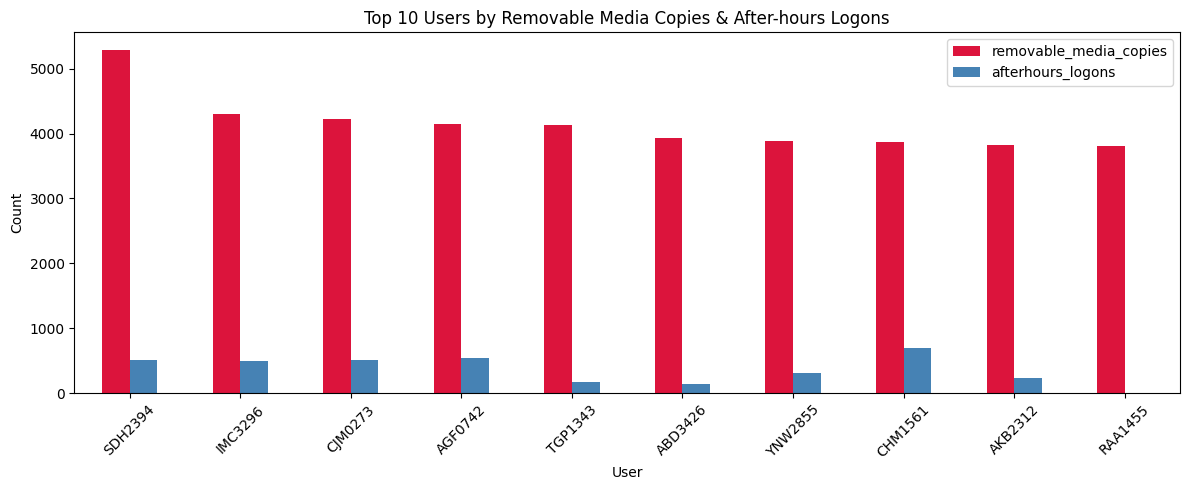

In [14]:
#Plot top suspicious users (most removable media copies)
import matplotlib.pyplot as plt
#Plot of  top suspicious users
top_suspicious = df.nlargest(10, 'removable_media_copies')[
    ['user_id', 'removable_media_copies', 'afterhours_logons']
]

top_suspicious.plot(
    x='user_id',
    kind='bar',
    figsize=(12,5),
    color=['crimson','steelblue']
)

plt.title('Top 10 Users by Removable Media Copies & After-hours Logons')
plt.xlabel('User')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
#dnn model build
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
#prepare features
#drop non-numeric columns for now
features = df.drop(columns=['user_id', 'role', 'department'])
features = features.fillna(0)

print("Features shape:", features.shape)
print("Columns used:", features.columns.tolist())

Features shape: (4000, 11)
Columns used: ['total_logons', 'afterhours_logons', 'weekend_logons', 'unique_pcs_x', 'total_file_actions', 'removable_media_copies', 'files_from_removable', 'unique_pcs_y', 'total_device_events', 'device_connects', 'device_disconnects']


In [16]:
#normalizing
scaler = StandardScaler()
X = scaler.fit_transform(features)
print("Data normalized!")
print("Shape:", X.shape)

Data normalized!
Shape: (4000, 11)


In [17]:
#risk label
#since we don't have labels yet so created simple rule based label
# users with high removable media + afterhours activity = suspicious
df['risk_label'] = (
    (df['removable_media_copies'] > df['removable_media_copies'].mean()) &
    (df['afterhours_logons'] > df['afterhours_logons'].mean())
).astype(int)

print("Risk labels created!")
print(df['risk_label'].value_counts())

Risk labels created!
risk_label
0    3690
1     310
Name: count, dtype: int64


In [18]:
#split data
from sklearn.model_selection import train_test_split
y = df['risk_label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Data split done!
Training samples: 3200
Testing samples:  800


In [19]:
#DNN model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  #binary threat or not
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#train DNN
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("DNN Training complete!")

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9262 - loss: 0.2209 - val_accuracy: 0.9609 - val_loss: 0.0908
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9508 - loss: 0.0977 - val_accuracy: 0.9750 - val_loss: 0.0756
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9652 - loss: 0.0739 - val_accuracy: 0.9891 - val_loss: 0.0513
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9770 - loss: 0.0612 - val_accuracy: 0.9922 - val_loss: 0.0396
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.0502 - val_accuracy: 0.9922 - val_loss: 0.0360
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9848 - loss: 0.0415 - val_accuracy: 0.9922 - val_loss: 0.0322
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9871 - loss: 0.0387 - val_accuracy: 0.9937 - val_loss: 0.0230
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9887 - loss: 0.0394 - val_accuracy: 0.9922 - val_loss:

In [21]:
#evaluate
from sklearn.metrics import classification_report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("DNN MODEL RESULTS")
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       741
           1       0.93      0.97      0.95        59

    accuracy                           0.99       800
   macro avg       0.97      0.98      0.97       800
weighted avg       0.99      0.99      0.99       800



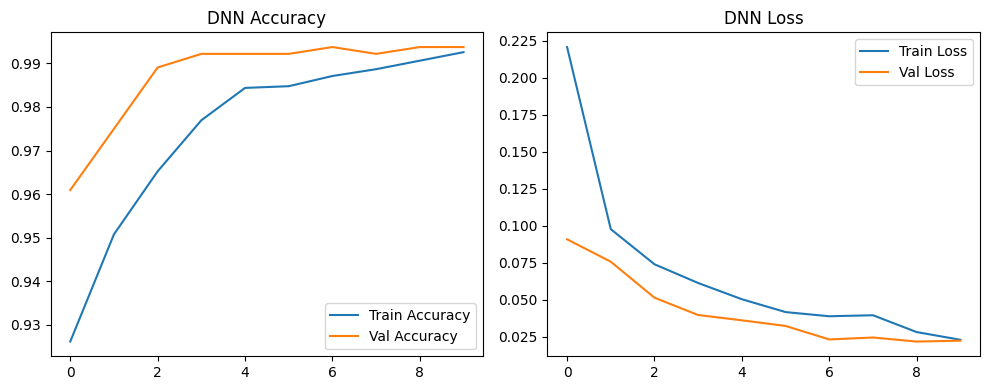

In [22]:
#plot of trainging history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Get DNN probability scores
dnn_scores = model.predict(X).flatten()
print("DNN scores ready, shape:", dnn_scores.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
DNN scores ready, shape: (4000,)


Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9299 - val_loss: 0.7806
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5863 - val_loss: 0.4931
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4712 - val_loss: 0.4624
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4557 - val_loss: 0.4534
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4501 - val_loss: 0.4483
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4469 - val_loss: 0.4443
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4440 - val_loss: 0.4422
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4415 - val_loss: 0.4403
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4393 - val_loss: 0.4384
Epoch 10/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4374 - val_loss: 0.4373
Epoch 11/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4360 - val_loss: 0.4361
Epoch 12/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

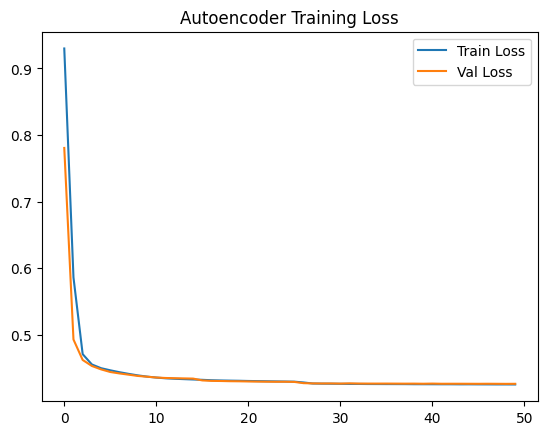

In [24]:
#Autoencoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt
import numpy as np

n_features = X.shape[1]

# Build Autoencoder
input_layer  = Input(shape=(n_features,))
encoded      = Dense(16, activation='relu')(input_layer)
bottleneck   = Dense(8,  activation='relu')(encoded)
decoded      = Dense(16, activation='relu')(bottleneck)
output_layer = Dense(n_features, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train only on normal users
y = df['risk_label'].values
X_normal = X[y == 0]

history_ae = autoencoder.fit(
    X_normal, X_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot
plt.plot(history_ae.history['loss'],     label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


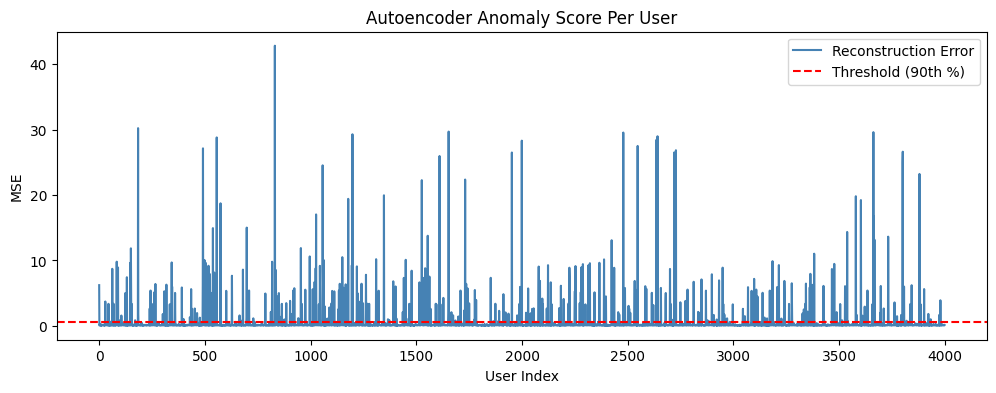

 Autoencoder flagged 400 suspicious users


In [25]:
#Anamoly detection
reconstructions = autoencoder.predict(X)
mse = ((X - reconstructions) ** 2).mean(axis=1)

threshold = np.percentile(mse, 90)
df['autoencoder_score'] = mse
df['ae_flagged'] = (mse > threshold).astype(int)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(mse, color='steelblue', label='Reconstruction Error')
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold (90th %)')
plt.title('Autoencoder Anomaly Score Per User')
plt.xlabel('User Index')
plt.ylabel('MSE')
plt.legend()
plt.show()

print(f" Autoencoder flagged {df['ae_flagged'].sum()} suspicious users")

In [26]:
#CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split

# Reshape for CNN
X_cnn = X.reshape(X.shape[0], X.shape[1], 1)
y_cnn = df['risk_label'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42)

# Build CNN
cnn = Sequential([
    Conv1D(32, kernel_size=2, activation='relu',
           input_shape=(n_features, 1)),
    MaxPooling1D(pool_size=1),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

cnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

history_cnn = cnn.fit(
    X_train_c, y_train_c,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_c, y_test_c),
    verbose=1
)

loss, acc = cnn.evaluate(X_test_c, y_test_c, verbose=0)
print(f"\nCNN Accuracy: {acc*100:.2f}%")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9362 - loss: 0.2138 - val_accuracy: 0.9688 - val_loss: 0.0738
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9794 - loss: 0.0667 - val_accuracy: 0.9937 - val_loss: 0.0406
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9922 - loss: 0.0391 - val_accuracy: 0.9962 - val_loss: 0.0236
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9944 - loss: 0.0250 - val_accuracy: 0.9975 - val_loss: 0.0154
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9953 - loss: 0.0190 - val_accuracy: 0.9962 - val_loss: 0.0130
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9962 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9978 - loss: 0.0112 - val_accuracy: 0.9975 - val_loss: 0.0085
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9966 - loss: 0.0105 - val_accuracy: 1.0000 - val_

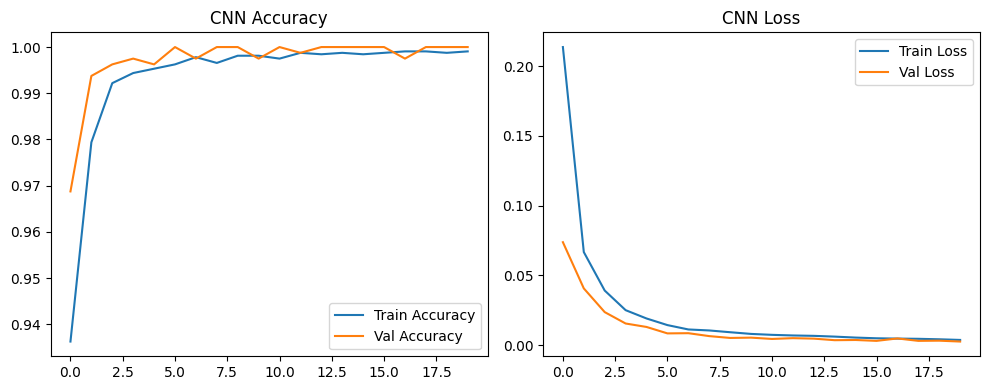

In [27]:
#CNN Training Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'],     label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'],     label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
#Risk Score
 # Get CNN scores
cnn_scores = cnn.predict(X_cnn).flatten()

# Normalize autoencoder scores to 0-1
ae_scores = (mse - mse.min()) / (mse.max() - mse.min())

# Normalize DNN scores (already 0-1 from sigmoid)

risk_score = (0.33 * dnn_scores) + \
             (0.33 * cnn_scores) + \
             (0.33 * ae_scores)

df['risk_score'] = risk_score
df['final_threat'] = (risk_score > 0.5).astype(int)

print("\n TOP 10 HIGH RISK USERS:")
print(df[['user_id', 'role', 'department', 'risk_score']]
      .sort_values('risk_score', ascending=False)
      .head(10))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

 TOP 10 HIGH RISK USERS:
      user_id     role    department  risk_score
831   BPD2437  ITAdmin  5 - Security    0.990000
184   CHB1062  ITAdmin  5 - Security    0.892836
1653  EPI3052  ITAdmin  5 - Security    0.888789
3662  LEB1764  ITAdmin  5 - Security    0.888125
2479  CAM3050  ITAdmin  5 - Security    0.887653
1198  KAC1774  ITAdmin  5 - Security    0.885631
2641  DLM2440  ITAdmin  5 - Security    0.883280
556   QAH0048  ITAdmin  5 - Security    0.881918
2636  BMM0462  ITAdmin  5 - Security    0.879098
1999  MAB1775  ITAdmin  5 - Security    0.878113


In [29]:
#Final evaluation matrix
from sklearn.metrics import classification_report, roc_auc_score

y_true = df['risk_label'].values
y_pred_final = df['final_threat'].values

print("=" * 40)
print("FINAL COMBINED MODEL RESULTS")
print("=" * 40)
print(classification_report(y_true, y_pred_final))
print(f"AUC-ROC Score: {roc_auc_score(y_true, risk_score):.4f}")

FINAL COMBINED MODEL RESULTS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3690
           1       1.00      0.97      0.98       310

    accuracy                           1.00      4000
   macro avg       1.00      0.98      0.99      4000
weighted avg       1.00      1.00      1.00      4000

AUC-ROC Score: 0.9999


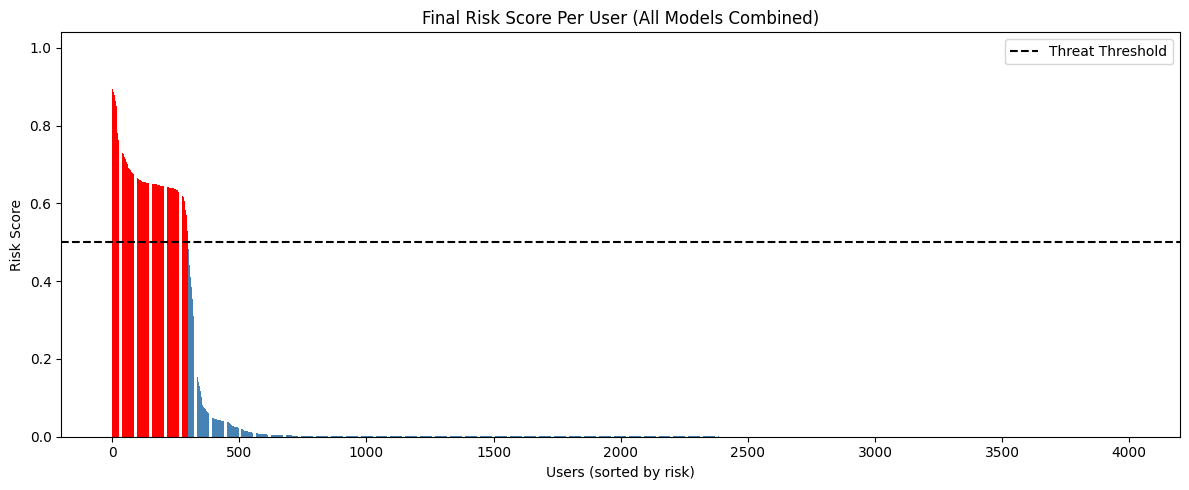

In [30]:
#Risk Score plot
plt.figure(figsize=(12, 5))
plt.bar(range(len(risk_score)),
        sorted(risk_score, reverse=True),
        color=['red' if s > 0.5 else 'steelblue'
               for s in sorted(risk_score, reverse=True)])
plt.axhline(y=0.5, color='black', linestyle='--', label='Threat Threshold')
plt.title('Final Risk Score Per User (All Models Combined)')
plt.xlabel('Users (sorted by risk)')
plt.ylabel('Risk Score')
plt.legend()
plt.tight_layout()
plt.show()